# Customer Segmentation & Churn Prediction
Brief intro: dataset, goal, approach

## 1. Data Loading & Cleaning
[code: load + clean]

## 2. RFM Feature Engineering
[code: RFM calculation]
Markdown: explain what R, F, M mean and why they matter

## 3. Customer Segmentation (K-Means)
[code: elbow method]
[code: clustering + cluster_summary]
Markdown: explain the 4 segments and what each represents

## 4. Churn Definition
[code: churn flag]
Markdown: why 90 days, churn rate observed

## 5. Churn Prediction Model
[code: train/test split]
[code: logistic regression - first attempt]
Markdown: **explain the data leakage issue** - this is important, shows real understanding
[code: fixed version without Recency]
[code: class_weight fix]
[code: random forest comparison]
Markdown: compare both models, explain why you chose Logistic Regression

## 6. Business Insights
[code: segment insight table]
Markdown: write out the interpretation (At Risk/Lost, Regular = priority, etc.)

## 7. Export for Dashboard
[code: export CSV/JSON]

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('online_retail_II.csv')

print(df.columns.tolist())
print(df.shape)
print(df.head())
print(df.dtypes)

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
(212296, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS      12.0   
1  489434    79323P                   PINK CHERRY LIGHTS      12.0   
2  489434    79323W                  WHITE CHERRY LIGHTS      12.0   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE       48.0   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX      24.0   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
Invoice         object
StockCode       object
Description     object
Quantity       float64
Invoice

In [4]:
# --- CLEANING ---
df = df.dropna(subset=['Customer ID'])
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['Price']

print("After cleaning:", df.shape)

After cleaning: (160101, 9)


In [5]:
# --- SNAPSHOT DATE ---
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)


In [6]:
# --- RFM CALCULATION ---
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm.reset_index()

print(rfm.shape)
print(rfm.head())
print(rfm.describe())

(2671, 4)
   Customer ID  Recency  Frequency  Monetary
0      12346.0       86         10    230.55
1      12349.0        9          2   1268.52
2      12355.0        6          1    488.21
3      12358.0      170          1   1429.83
4      12359.0       65          4   1522.23
        Customer ID      Recency    Frequency       Monetary
count   2671.000000  2671.000000  2671.000000    2671.000000
mean   15342.867091    59.256084     2.871584    1338.120528
std     1685.672257    49.819821     4.528766    5252.607955
min    12346.000000     1.000000     1.000000       1.300000
25%    13885.500000    18.000000     1.000000     258.715000
50%    15323.000000    44.000000     2.000000     512.540000
75%    16811.500000    87.000000     3.000000    1122.375000
max    18287.000000   177.000000    71.000000  154566.350000


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [8]:
# Scale the RFM values
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

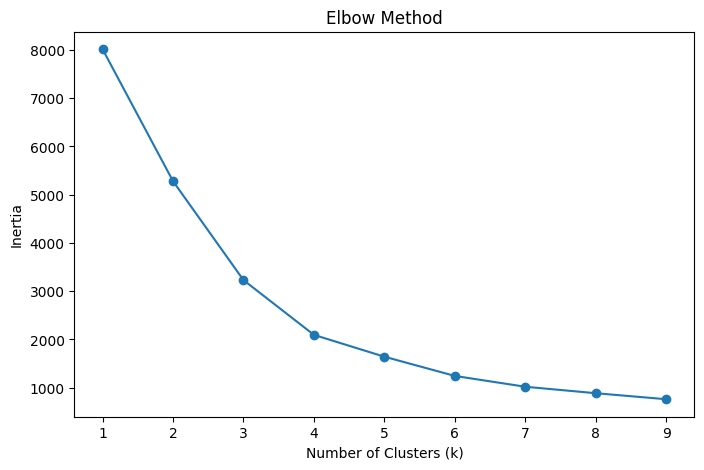

In [9]:
# Elbow method to find optimal k
inertia = []
K_range = range(1, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [11]:
# Final clustering with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [12]:
# Check cluster sizes
print(rfm['Cluster'].value_counts())


Cluster
3    1802
1     835
0      29
2       5
Name: count, dtype: int64


In [13]:
# Average RFM values per cluster
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print(cluster_summary)

            Recency  Frequency       Monetary
Cluster                                      
0          7.172414  30.689655   16957.768000
1        122.411976   1.385629     460.235705
2          9.000000  52.600000  103392.100000
3         30.968923   2.974473    1210.370336


In [15]:
segment_map = {
    2: 'VIP/Whale',
    0: 'Champions',
    3: 'Regular',
    1: 'At Risk/Lost'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

print(rfm['Segment'].value_counts())


Segment
Regular         1802
At Risk/Lost     835
Champions         29
VIP/Whale          5
Name: count, dtype: int64


In [16]:
print(rfm.head(10))

   Customer ID  Recency  Frequency  Monetary  Cluster       Segment
0      12346.0       86         10    230.55        3       Regular
1      12349.0        9          2   1268.52        3       Regular
2      12355.0        6          1    488.21        3       Regular
3      12358.0      170          1   1429.83        1  At Risk/Lost
4      12359.0       65          4   1522.23        3       Regular
5      12360.0        2          3    780.04        3       Regular
6      12361.0       17          2    207.35        3       Regular
7      12362.0      177          1    130.00        1  At Risk/Lost
8      12366.0       72          1    500.24        3       Regular
9      12368.0       66          1    917.70        3       Regular


###Phase 3: Churn Prediction

In [18]:
rfm['Churned'] = (rfm['Recency'] > 90).astype(int)

print(rfm['Churned'].value_counts())

Churned
0    2028
1     643
Name: count, dtype: int64


In [19]:
# Check churn rate by segment
print(rfm.groupby('Segment')['Churned'].mean())

Segment
At Risk/Lost    0.77006
Champions       0.00000
Regular         0.00000
VIP/Whale       0.00000
Name: Churned, dtype: float64


In [20]:
print(rfm['Churned'].value_counts(normalize=True))  # percentage


Churned
0    0.759266
1    0.240734
Name: proportion, dtype: float64


In [21]:
from sklearn.model_selection import train_test_split

# Features and target
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churned']

In [22]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())

Train shape: (2136, 3)
Test shape: (535, 3)
Train churn rate: 0.2406367041198502
Test churn rate: 0.2411214953271028


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [24]:
# Train model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [25]:
# Predictions
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0
ROC-AUC: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       406
           1       1.00      1.00      1.00       129

    accuracy                           1.00       535
   macro avg       1.00      1.00      1.00       535
weighted avg       1.00      1.00      1.00       535



In [27]:
# Features WITHOUT Recency (avoid leakage)
X = rfm[['Frequency', 'Monetary']]
y = rfm['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [28]:
log_reg = LogisticRegression(random_state=42, class_weight='balanced')
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.680373831775701
ROC-AUC: 0.7603963798831481

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.66      0.76       406
           1       0.41      0.76      0.53       129

    accuracy                           0.68       535
   macro avg       0.65      0.71      0.65       535
weighted avg       0.78      0.68      0.70       535



In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))


Accuracy: 0.7009345794392523
ROC-AUC: 0.6764902432504678

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80       406
           1       0.38      0.40      0.39       129

    accuracy                           0.70       535
   macro avg       0.59      0.60      0.60       535
weighted avg       0.70      0.70      0.70       535



In [30]:
# Feature importance
import pandas as pd
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(importance)


Feature Importance:
     Feature  Importance
1   Monetary    0.853992
0  Frequency    0.146008


In [31]:
# Add churn probability from Logistic Regression to the full dataset
rfm['Churn_Probability'] = log_reg.predict_proba(X)[:, 1]



In [32]:
# Cross-tab: segment vs average churn probability and value
insight_table = rfm.groupby('Segment').agg({
    'Customer ID': 'count',
    'Monetary': 'mean',
    'Churn_Probability': 'mean'
}).rename(columns={'Customer ID': 'Num_Customers', 'Monetary': 'Avg_Value'})

insight_table = insight_table.sort_values('Churn_Probability', ascending=False)
print(insight_table)

              Num_Customers      Avg_Value  Churn_Probability
Segment                                                      
At Risk/Lost            835     460.235705       5.960885e-01
Regular                1802    1210.370336       3.854355e-01
Champions                29   16957.768000       1.402369e-07
VIP/Whale                 5  103392.100000       4.782316e-21


In [33]:
import json

# Export RFM table with segments and churn probability
rfm_export = rfm[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Segment', 'Churn_Probability']]
rfm_export.to_csv('rfm_results.csv', index=False)

In [34]:
# Export summary insight table as JSON for the dashboard
insight_dict = insight_table.reset_index().to_dict(orient='records')
with open('segment_insights.json', 'w') as f:
    json.dump(insight_dict, f, indent=2)

print("Files saved: rfm_results.csv, segment_insights.json")
print(insight_dict)

Files saved: rfm_results.csv, segment_insights.json
[{'Segment': 'At Risk/Lost', 'Num_Customers': 835, 'Avg_Value': 460.23570538922155, 'Churn_Probability': 0.5960884983749961}, {'Segment': 'Regular', 'Num_Customers': 1802, 'Avg_Value': 1210.370335738069, 'Churn_Probability': 0.3854354946881359}, {'Segment': 'Champions', 'Num_Customers': 29, 'Avg_Value': 16957.768, 'Churn_Probability': 1.4023686408307495e-07}, {'Segment': 'VIP/Whale', 'Num_Customers': 5, 'Avg_Value': 103392.1, 'Churn_Probability': 4.782316261187777e-21}]
